<a href="https://colab.research.google.com/github/AlanSojan15/ML_Lab/blob/Lab7/2547208_ML_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=================== TASK 1 ===================
Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=====

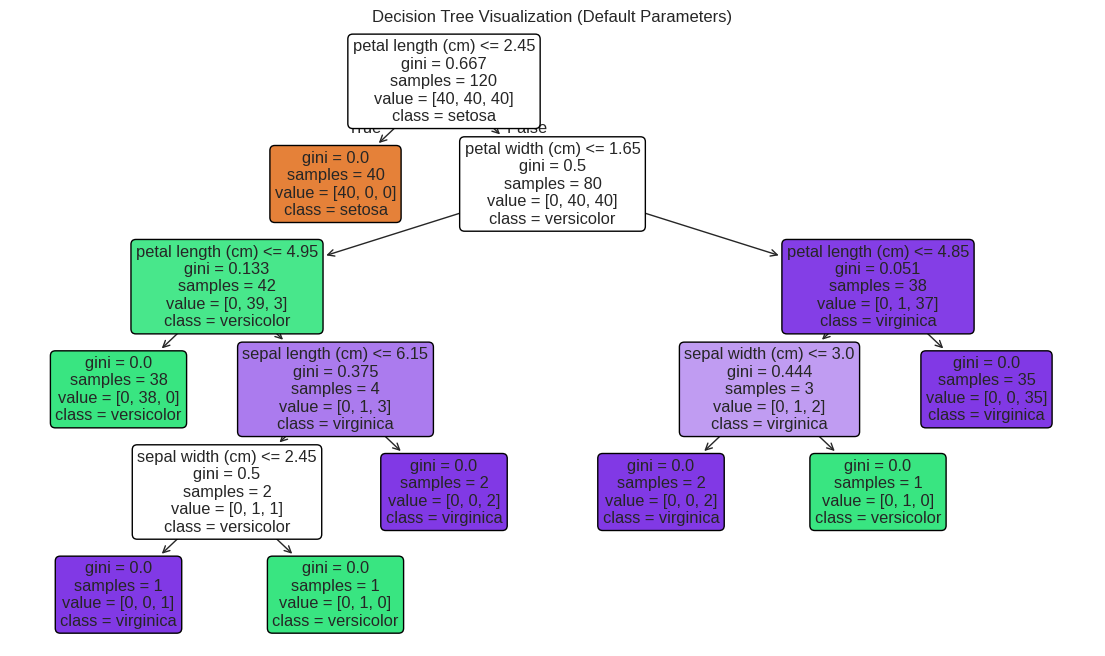

Maximum Depth of Tree: 5
Number of Leaves: 8
First split feature: petal length (cm)

=================== TASK 5 ===================
      Metric/Property        Gini Index           Entropy
             Accuracy            0.9333            0.9333
           Tree Depth                 5                 5
 Number of Leaf Nodes                 8                 8
Root Feature Selected petal length (cm) petal length (cm)

=================== TASK 6 ===================
Max Depth Training Accuracy Testing Accuracy  Tree Depth                            Observation
        1            0.6667           0.6667           1     Underfitting (stump, low capacity)
        2            0.9667           0.9333           2                      Good, simple tree
        3            0.9833           0.9667           3                 Optimal generalization
        4            0.9917           0.9333           4            Near identical to full tree
     None            1.0000           0.9333      

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ==========================================
# Task 1: Dataset Exploration
# ==========================================
print("=================== TASK 1 ===================")
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(target_names)})

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature names: {feature_names}")
print(f"Target classes: {list(target_names)}")

print("\nFirst five records:")
print(df.head())

print("\nClass distribution:")
print(df['species'].value_counts())

# ==========================================
# Task 2: Data Preparation
# ==========================================
print("\n=================== TASK 2 ===================")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# ==========================================
# Task 3: Building a Decision Tree Classifier
# ==========================================
print("\n=================== TASK 3 ===================")
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred = dt_default.predict(X_test)

acc_default = accuracy_score(y_test, y_pred)
cm_default = confusion_matrix(y_test, y_pred)
cr_default = classification_report(y_test, y_pred, target_names=target_names)

print(f"Accuracy Score: {acc_default:.4f}")
print("\nConfusion Matrix:")
print(cm_default)
print("\nClassification Report:")
print(cr_default)

# ==========================================
# Task 4: Visualizing the Decision Tree
# ==========================================
print("\n=================== TASK 4 ===================")
plt.figure(figsize=(14, 8))
plot_tree(
    dt_default,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization (Default Parameters)")
plt.show()

print(f"Maximum Depth of Tree: {dt_default.get_depth()}")
print(f"Number of Leaves: {dt_default.get_n_leaves()}")
print(f"First split feature: {feature_names[dt_default.tree_.feature[0]]}")

# ==========================================
# Task 5: Comparing Gini Index and Entropy
# ==========================================
print("\n=================== TASK 5 ===================")
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

comp_data = {
    'Metric/Property': ['Accuracy', 'Tree Depth', 'Number of Leaf Nodes', 'Root Feature Selected'],
    'Gini Index': [
        f"{accuracy_score(y_test, y_pred_gini):.4f}",
        dt_gini.get_depth(),
        dt_gini.get_n_leaves(),
        feature_names[dt_gini.tree_.feature[0]]
    ],
    'Entropy': [
        f"{accuracy_score(y_test, y_pred_entropy):.4f}",
        dt_entropy.get_depth(),
        dt_entropy.get_n_leaves(),
        feature_names[dt_entropy.tree_.feature[0]]
    ]
}
df_comp = pd.DataFrame(comp_data)
print(df_comp.to_string(index=False))

# ==========================================
# Task 6: Effect of Maximum Tree Depth
# ==========================================
print("\n=================== TASK 6 ===================")
max_depths = [1, 2, 3, 4, None]
task6_results = []

for md in max_depths:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()

    if md == 1:
        obs = "Underfitting (stump, low capacity)"
    elif md == 2:
        obs = "Good, simple tree"
    elif md == 3:
        obs = "Optimal generalization"
    elif md == 4:
        obs = "Near identical to full tree"
    else:
        obs = "Fully expanded (potential overfitting)"

    task6_results.append({
        'Max Depth': str(md),
        'Training Accuracy': f"{tr_acc:.4f}",
        'Testing Accuracy': f"{te_acc:.4f}",
        'Tree Depth': depth,
        'Observation': obs
    })

df_task6 = pd.DataFrame(task6_results)
print(df_task6.to_string(index=False))

# ==========================================
# Task 7: Effect of min_samples_split
# ==========================================
print("\n=================== TASK 7 ===================")
min_splits = [2, 5, 10, 20]
task7_results = []

for mss in min_splits:
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    clf.fit(X_train, y_train)

    acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()
    leaves = clf.get_n_leaves()

    if mss == 2:
        obs = "Fully complex tree"
    elif mss in [5, 10]:
        obs = "Slight regularization"
    else:
        obs = "Restricts early node splitting"

    task7_results.append({
        'min_samples_split': mss,
        'Accuracy': f"{acc:.4f}",
        'Tree Depth': depth,
        'Number of Leaf Nodes': leaves,
        'Observation': obs
    })

df_task7 = pd.DataFrame(task7_results)
print(df_task7.to_string(index=False))

# ==========================================
# Task 8: Effect of min_samples_leaf
# ==========================================
print("\n=================== TASK 8 ===================")
min_leaves = [1, 2, 5, 10]
task8_results = []

for msl in min_leaves:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)

    acc = accuracy_score(y_test, clf.predict(X_test))
    depth = clf.get_depth()
    leaves = clf.get_n_leaves()

    if msl == 1:
        obs = "Unconstrained leaf size"
    elif msl == 2:
        obs = "Prunes isolated single-sample leaves"
    else:
        obs = "Smoother decision boundaries"

    task8_results.append({
        'min_samples_leaf': msl,
        'Accuracy': f"{acc:.4f}",
        'Tree Depth': depth,
        'Number of Leaf Nodes': leaves,
        'Observation': obs
    })

df_task8 = pd.DataFrame(task8_results)
print(df_task8.to_string(index=False))

# ==========================================
# Task 9: Hyperparameter Tuning
# ==========================================
print("\n=================== TASK 9 ===================")
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
opt_test_acc = accuracy_score(y_test, y_pred_opt)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best 5-Fold CV Score: {grid_search.best_score_:.4f}")
print(f"Optimized Model Test Accuracy: {opt_test_acc:.4f}")
print(f"Default Model Test Accuracy:   {acc_default:.4f}")